**# MERGER DATA**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# ==============================================================================
# MERGER DATA
# ==============================================================================

# --------------------------
# 1. DATASET
# --------------------------
df1 = pd.read_csv('data_jumlah_puskesmas.csv')
df2 = pd.read_csv('data_jumlah_tenagakesehatan.csv')
df3 = pd.read_csv('data_jumlah_penyakittidakmenular.csv')
df4 = pd.read_csv('data_jumlah_penyakitmenular.csv')
df5 = pd.read_csv('data_jumlah_penduduk.csv')

datasets = [df1, df2, df3, df4, df5]

# --------------------------
# 2. STANDARISASI NAMA KOLOM
# --------------------------
for df in datasets:
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
    )

# --------------------------
# 3. STANDARISASI WILAYAH & TAHUN
# --------------------------
for df in datasets:

    df['nama_kabupaten_kota'] = (
        df['nama_kabupaten_kota']
        .str.upper()
        .str.strip()
    )

    df['tahun'] = (
        df['tahun']
        .astype(str)
        .str.extract(r'(\d{4})')[0]
        .astype(int)
    )

# --------------------------
# 4. MERGE 5 DATASET
# --------------------------
df_merged = datasets[0]

for i in range(1, len(datasets)):
    df_merged = df_merged.merge(
        datasets[i],
        on=[
            'kode_kabupaten_kota',
            'nama_kabupaten_kota',
            'tahun'
        ],
        how='outer'
    )

# --------------------------
# 5. FILTER TAHUN
# --------------------------
df_merged = df_merged[
    df_merged['tahun'].between(2018, 2024)
]


# --------------------------
# 6. SORT DATA
# --------------------------
df_merged = df_merged.sort_values(
    ['tahun', 'kode_kabupaten_kota']
).reset_index(drop=True)


df_merged = df_merged.drop(columns=['unnamed:_0'], errors='ignore')


df_merged


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,9,15,347,141,619,41173,292,592938
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,12,19,519,129,990,46778,479,962125
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,3,19,384,227,792,40464,285,748432
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1109547
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,6,18,540,233,837,65232,392,1230159
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,8,0,1,0,261,18844,287,213469
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,6,0,4,0,396,16010,129,142272
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,6,0,5,0,521,23764,756,201733
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,40,23,69,0,7446,851331,2299,3018022



 1. Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   kode_provinsi                  266 non-null    object
 1   nama_provinsi                  266 non-null    object
 2   kode_kabupaten_kota            266 non-null    object
 3   nama_kabupaten_kota            266 non-null    object
 4   tahun                          266 non-null    int64 
 5   pelayanan_non_rawat_inap       266 non-null    int64 
 6   pelayanan_rawat_inap           266 non-null    int64 
 7   jumlah_bidan                   266 non-null    int64 
 8   jumlah_dokter                  266 non-null    int64 
 9   jumlah_perawat                 266 non-null    int64 
 10  jumlah_penyakit_tidak_menular  266 non-null    int64 
 11  jumlah_penyakit_menular        266 non-null    int64 
 12  jumlah_penduduk                266 non-null    i

,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap
36,KOTA SURABAYA,2018,41
74,KOTA SURABAYA,2019,41
112,KOTA SURABAYA,2020,41
150,KOTA SURABAYA,2021,41
188,KOTA SURABAYA,2022,41
226,KOTA SURABAYA,2023,41
264,KOTA SURABAYA,2024,40



Variabel: pelayanan_rawat_inap
Jumlah Outlier: 4


,nama_kabupaten_kota,tahun,pelayanan_rawat_inap
122,KABUPATEN JEMBER,2021,43
160,KABUPATEN JEMBER,2022,43
198,KABUPATEN JEMBER,2023,43
236,KABUPATEN JEMBER,2024,43



Variabel: jumlah_bidan
Jumlah Outlier: 2


...


Variabel: jumlah_penyakit_menular
Jumlah Outlier: 29


,nama_kabupaten_kota,tahun,jumlah_penyakit_menular
90,KABUPATEN SIDOARJO,2020,8567
112,KOTA SURABAYA,2020,19070
114,KABUPATEN PACITAN,2021,7600
115,KABUPATEN PONOROGO,2021,11496
116,KABUPATEN TRENGGALEK,2021,7331
117,KABUPATEN TULUNGAGUNG,2021,7423
118,KABUPATEN BLITAR,2021,9261
119,KABUPATEN KEDIRI,2021,12133
120,KABUPATEN MALANG,2021,13586
122,KABUPATEN JEMBER,2021,12929



Variabel: jumlah_penduduk
Jumlah Outlier: 21


,nama_kabupaten_kota,tahun,jumlah_penduduk
6,KABUPATEN MALANG,2018,2492110
8,KABUPATEN JEMBER,2018,2556614
36,KOTA SURABAYA,2018,2915910
44,KABUPATEN MALANG,2019,2549807
46,KABUPATEN JEMBER,2019,2568884
74,KOTA SURABAYA,2019,2950230
82,KABUPATEN MALANG,2020,2585426
84,KABUPATEN JEMBER,2020,2578949
112,KOTA SURABAYA,2020,2970730
120,KABUPATEN MALANG,2021,2635950



VISUALISASI OUTLIER


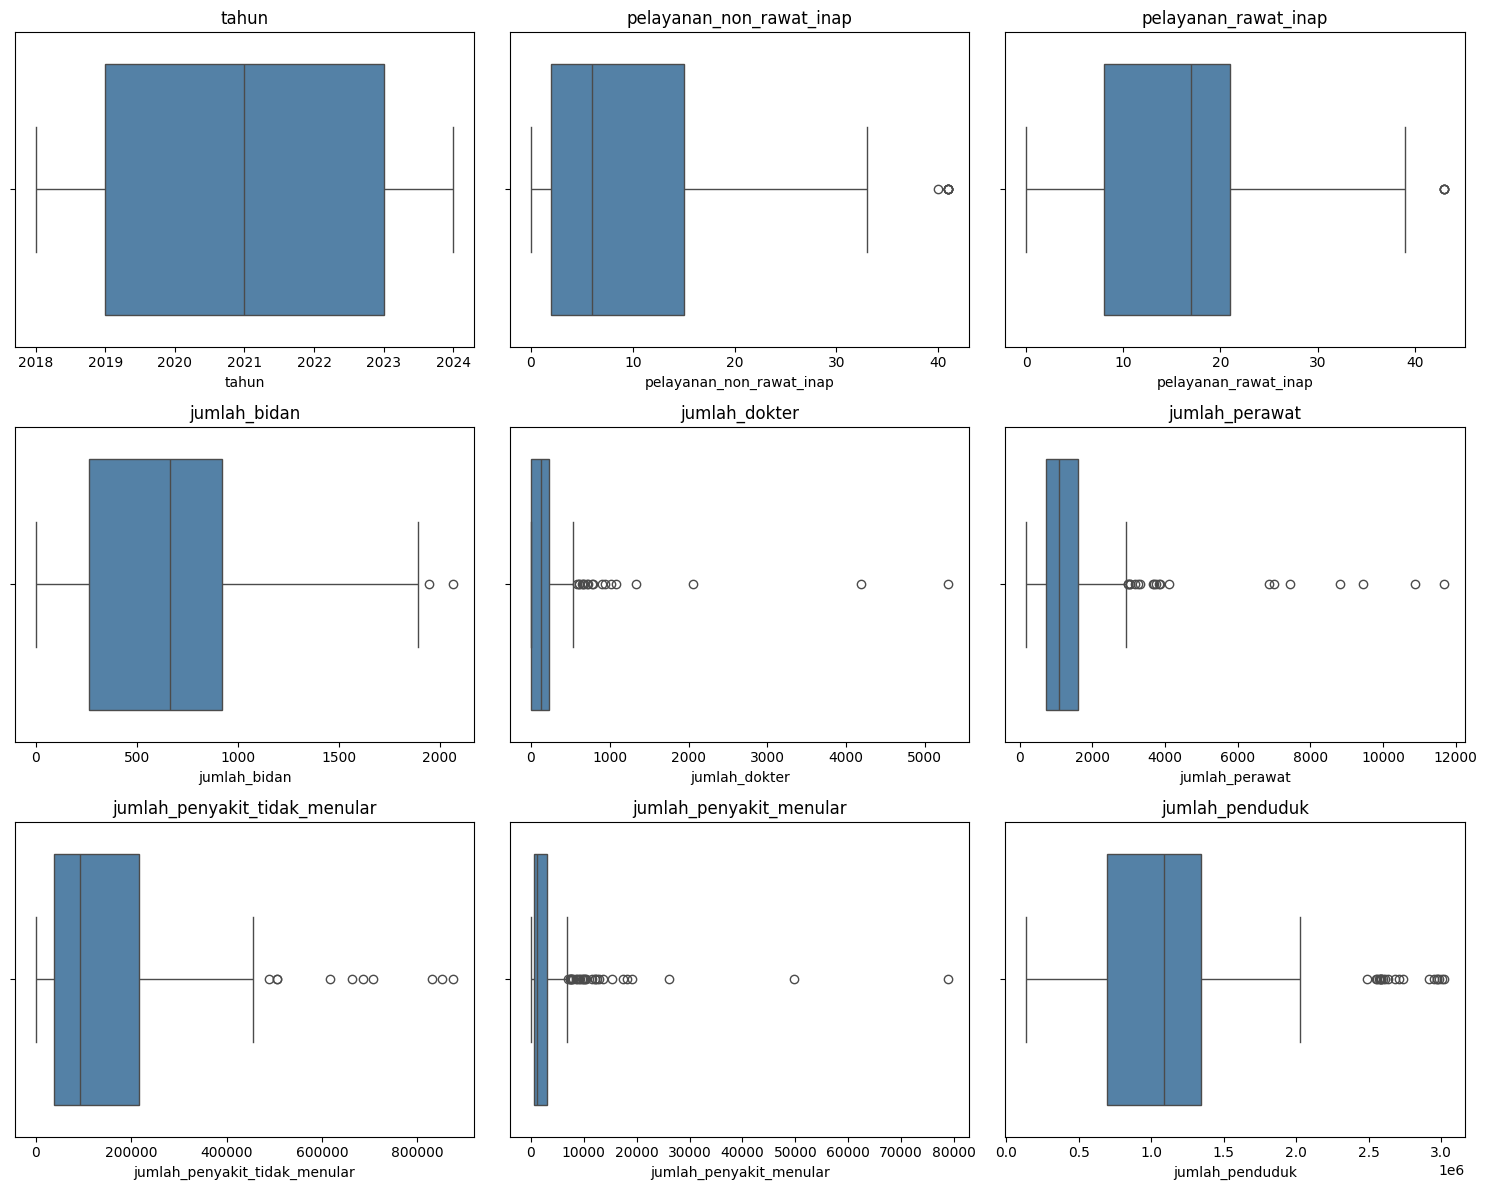

In [6]:
# ==============================================================================
# DATA MERGED CLEANING
# ==============================================================================

# -------------------------
# 1. INFO DATA
# -------------------------
print("\n 1. Info Data:")
df_merged.info()

print("\n Info Data Setelah Konversi ke String (selain jumlah dan tahun)")
kolom_string = [
    'kode_provinsi',
    'kode_kabupaten_kota'
]

df_merged[kolom_string] = df_merged[kolom_string].astype(str)

df_merged.info()

# -------------------------
# 2. STANDARDISASI KAB/KOT
# -------------------------
df_merged['nama_kabupaten_kota'] = (
    df_merged['nama_kabupaten_kota']
    .str.upper()
    .str.strip()
)

daftar_kabkot = [
    'KABUPATEN PACITAN',
    'KABUPATEN PONOROGO',
    'KABUPATEN TRENGGALEK',
    'KABUPATEN TULUNGAGUNG',
    'KABUPATEN BLITAR',
    'KABUPATEN KEDIRI',
    'KABUPATEN MALANG',
    'KABUPATEN LUMAJANG',
    'KABUPATEN JEMBER',
    'KABUPATEN BANYUWANGI',
    'KABUPATEN BONDOWOSO',
    'KABUPATEN SITUBONDO',
    'KABUPATEN PROBOLINGGO',
    'KABUPATEN PASURUAN',
    'KABUPATEN SIDOARJO',
    'KABUPATEN MOJOKERTO',
    'KABUPATEN JOMBANG',
    'KABUPATEN NGANJUK',
    'KABUPATEN MADIUN',
    'KABUPATEN MAGETAN',
    'KABUPATEN NGAWI',
    'KABUPATEN BOJONEGORO',
    'KABUPATEN TUBAN',
    'KABUPATEN LAMONGAN',
    'KABUPATEN GRESIK',
    'KABUPATEN BANGKALAN',
    'KABUPATEN SAMPANG',
    'KABUPATEN PAMEKASAN',
    'KABUPATEN SUMENEP',
    'KOTA KEDIRI',
    'KOTA BLITAR',
    'KOTA MALANG',
    'KOTA PROBOLINGGO',
    'KOTA PASURUAN',
    'KOTA MOJOKERTO',
    'KOTA MADIUN',
    'KOTA SURABAYA',
    'KOTA BATU'
]

# -------------------------
# 3. CEK KELENGKAPAN KAB/KOT
# -------------------------
tidak_ada = [
    nama for nama in daftar_kabkot
    if nama not in df_merged['nama_kabupaten_kota'].values
]

print("\n2.Cek Kelengkapan Kabupaten/Kota")

if len(tidak_ada) > 0:
    print("Nama Kabupaten/kota yang tidak ada di dataset:")
    for nama in tidak_ada:
        print(nama)
else:
    print("Semua nama kabupaten/kota tersedia di dataset")

# -------------------------
# 4. CEK DUPLIKAT
# -------------------------
jumlah_duplikat = df_merged.duplicated().sum()

print("\n3.Cek Data Duplikat")

if jumlah_duplikat > 0:
    print("Jumlah data duplikat:", jumlah_duplikat)
    df_merged = df_merged.drop_duplicates()
    print("Berhasil dihapus")
else:
    print("Tidak ada data duplikat")


# -------------------------
# 5. CEK MISSING VALUE
# -------------------------
missing_value = df_merged.isnull().sum()

print("\n4.Cek Missing Value")

if missing_value.sum() > 0:
    print("Jumlah missing value:", missing_value.sum())
    kolom_numerik = df_merged.select_dtypes(include='number').columns
    for kolom in kolom_numerik:
        df_merged[kolom] = df_merged[kolom].fillna(df_merged[kolom].median())
    print("Berhasil ditangani")

else:
    print("Tidak ada missing value")


# -------------------------
# 6. CEK OUTLIER (IQR)
# -------------------------
hasil_outlier = []
kolom_numerik = df_merged.select_dtypes(include='number').columns

print("kolom numerik:", kolom_numerik)
print("\n5.Cek Outlier (IQR)")

for kolom in kolom_numerik:

    Q1 = df_merged[kolom].quantile(0.25)
    Q3 = df_merged[kolom].quantile(0.75)

    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    jumlah_outlier = df_merged[
        (df_merged[kolom] < batas_bawah) |
        (df_merged[kolom] > batas_atas)
    ]


    if len(jumlah_outlier) > 0:
        keterangan = "Ada outlier"
        print(f"\nVariabel: {kolom}")
        print(f'Jumlah Outlier: {len(jumlah_outlier)}')
        display(jumlah_outlier[['nama_kabupaten_kota', 'tahun', kolom]])
    else:
        print(f"\nVariabel: {kolom}")
        print("Tidak ada outlier")

print("\nVISUALISASI OUTLIER")

jumlah_kolom = len(kolom_numerik)
ncols = 3
nrows = math.ceil(jumlah_kolom / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(kolom_numerik):
    sns.boxplot(x=df_merged[col], color='steelblue', ax=axes[i])

    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [5]:
# =====================================================
# 9. SIMPAN
# =====================================================
df_merged.to_csv(
    "dataset_fasilitas_kesehatan_skripsi_kedua.csv",
    index=False,
    float_format="%.0f"
)